In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("C:/Users/preet/Desktop/ML/Datasets/loan_data_ld.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

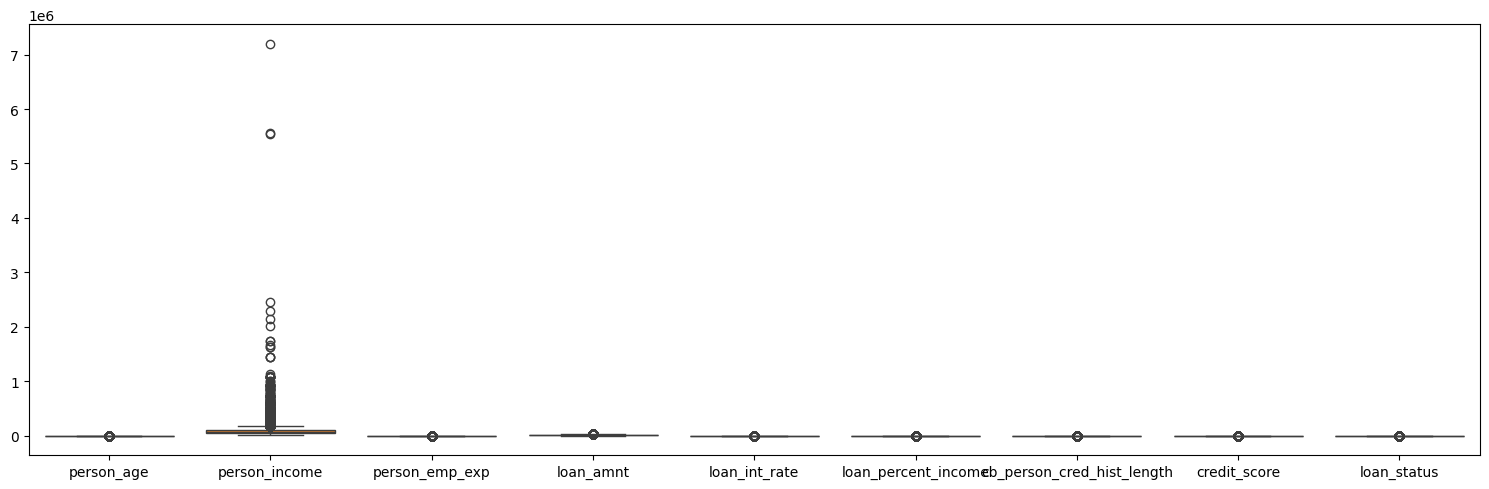

In [4]:
plt.figure(figsize=(15,5))
sns.boxplot(df)
plt.tight_layout()

In [5]:
x = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [7]:
obj_cols = xtrain.select_dtypes(include="object").columns

def col_nunique(cols):
    for col in cols:
        print(f"Column Name - {col} --> No. of Unique values - {df[col].nunique()}")

col_nunique(obj_cols)

Column Name - person_gender --> No. of Unique values - 2
Column Name - person_education --> No. of Unique values - 5
Column Name - person_home_ownership --> No. of Unique values - 4
Column Name - loan_intent --> No. of Unique values - 6
Column Name - previous_loan_defaults_on_file --> No. of Unique values - 2


In [8]:
model = LogisticRegression(solver="liblinear", max_iter=1000)
encoder = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown="ignore")
scaler = StandardScaler()

In [9]:
trained = False

def feature_updation(xdata, type):
    global trained
    match type:
        case 'train':
            encode_values = encoder.fit_transform(xdata[obj_cols])
            trained = True
        
        case 'test':
            if trained:
                encode_values = encoder.transform(xdata[obj_cols])
            else:
                print("Model is not yet trained.")
        
        case _:
            print("Invalid Type.")
            return
        
    xdata[encoder.get_feature_names_out()] = encode_values
    return xdata.drop(obj_cols, axis = 1)

In [10]:
xtrain = feature_updation(xtrain, "train")
xtest = feature_updation(xtest, "test")

In [11]:
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [12]:
model.fit(xtrain, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [14]:
xtrain_pred = model.predict(xtrain)
xtest_pred = model.predict(xtest)
print(f"Confusion Matrix for trained data :\n{confusion_matrix(ytrain, xtrain_pred)}")
print()
print(f"Confusion Matrix for test data :\n{confusion_matrix(ytest, xtest_pred)}")

Confusion Matrix for trained data :
[[26311  1699]
 [ 2003  5987]]

Confusion Matrix for test data :
[[6557  433]
 [ 519 1491]]


__Confusion Matrix Conclusion for Trained Data__

    - Out of 36000 values, 32298 values are correctly predicted.
    - 3702 values are wrongly predicted.

__Confusion Matrix Conclusion for Test Data__

    - Out of 9000 values, 8048 values are correctly predicted.
    - 952 values are wrongly predicted.

In [15]:
print(f"Recall Score of trained data for 1 : {recall_score(ytrain, xtrain_pred, pos_label=1)}")
print(f"Recall Score of test data for 1 : {recall_score(ytest, xtest_pred, pos_label=1)}")

Recall Score of trained data for 1 : 0.7493116395494368
Recall Score of test data for 1 : 0.7417910447761195


__Recall Score Conclusion of trained data for 1__

    - Out of all actual 1 labels, 74 % are correctly predicted as 1.
    - 26 % are wrongly predicted as 0.

__Recall Score Conclusion of test data for 1__

    - Out of all actual 1 labels, 74 % are correctly predicted as 1.
    - 26 % are wrongly predicted as 0.

In [16]:
print(f"Recall Score of trained data for 0 : {recall_score(ytrain, xtrain_pred, pos_label=0)}")
print(f"Recall Score of test data for 0 : {recall_score(ytest, xtest_pred, pos_label=0)}")

Recall Score of trained data for 0 : 0.9393430917529454
Recall Score of test data for 0 : 0.9380543633762518


__Recall Score Conclusion of trained data for 0__

    - Out of all actual 0 labels, 93 % are correctly predicted as 0.
    - 7 % are wrongly predicted as 1.

__Recall Score Conclusion of test data for 0__

    - Out of all actual 0 labels, 93 % are correctly predicted as 0.
    - 7 % are wrongly predicted as 1.

In [17]:
print(f"Precision Score of trained data for 1 : {precision_score(ytrain, xtrain_pred, pos_label=1)}")
print(f"Precision Score of test data for 1 : {precision_score(ytest, xtest_pred, pos_label=1)}")

Precision Score of trained data for 1 : 0.7789487379651314
Precision Score of test data for 1 : 0.774948024948025


__Precision Score Conclusion of trained data for 1__

    - Out of all predicted 1 labels, 77 % are correctly predicted as 1.
    - 23 % are wrongly predicted as 1.

__Precision Score Conclusion of test data for 1__

    - Out of all predicted 1 labels, 77 % are correctly predicted as 1.
    - 23 % are wrongly predicted as 1.

In [18]:
print(f"Precision Score of trained data for 0 : {precision_score(ytrain, xtrain_pred, pos_label=0)}")
print(f"Precision Score of test data for 0 : {precision_score(ytest, xtest_pred, pos_label=0)}")

Precision Score of trained data for 0 : 0.9292576110757929
Precision Score of test data for 0 : 0.9266534765404183


__Precision Score Conclusion of trained data for 0__

    - Out of all predicted 0 labels, 92 % are correctly predicted as 0.
    - 8 % are wrongly predicted as 0.

__Precision Score Conclusion of test data for 0__

    - Out of all predicted 0 labels, 92 % are correctly predicted as 0.
    - 8 % are wrongly predicted as 0.

In [19]:
train_1 = f1_score(ytrain,xtrain_pred,pos_label=1)
test_1 = f1_score(ytest,xtest_pred,pos_label=1)
print(f"F1 Score of trained data for 1 : {train_1}")
print(f"F1 Score of test data for 1 : {test_1}")

F1 Score of trained data for 1 : 0.7638428170451645
F1 Score of test data for 1 : 0.7580071174377224


__F1 Score Conclusion of trained data for 1__

    - F1 score of trained data for 1 is 76 % as model is performing well for 1 label.

__F1 Score Conclusion of test data for 1__

    -F1 score of test data for 1 is 75 % as model is performing well for 1 label.

In [20]:
train_0 = f1_score(ytrain,xtrain_pred,pos_label=0)
test_0 = f1_score(ytest,xtest_pred,pos_label=0)
print(f"F1 Score of trained data for 0 : {train_0}")
print(f"F1 Score of test data for 0 : {test_0}")

F1 Score of trained data for 0 : 0.9342731340103686
F1 Score of test data for 0 : 0.9323190672543722


__F1 Score Conclusion of trained data for 0__

    - F1 score of trained data for 0 is 93 % as model is performing good for 0 label.

__F1 Score Conclusion of test data for 0__

    -F1 score of test data for 0 is 93 % as model is performing good for 0 label.

In [21]:
print(f"Overall F1 Score for train data : {(train_0+train_1)/2}")
print(f"Overall F1 Score for test data : {(test_0+test_1)/2}")

Overall F1 Score for train data : 0.8490579755277665
Overall F1 Score for test data : 0.8451630923460474


__Overall F1 Score Conclusion for train data__

    - Overall F1 score for train data is 84 %, so the model is performing good on train data.

__Overall F1 Score Conclusion for test data__

    - Overall F1 score for test data is 84 %, so the model is performing good on test data.

In [22]:
print(classification_report(ytrain,xtrain_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     28010
           1       0.78      0.75      0.76      7990

    accuracy                           0.90     36000
   macro avg       0.85      0.84      0.85     36000
weighted avg       0.90      0.90      0.90     36000



In [23]:
print(classification_report(ytest,xtest_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.89      0.89      9000

